In [64]:
#Install and import libraries

# Install packages if you need them
#%pip install pandas
#%pip install seaborn
#%pip install scipy

# Import packages
import pandas as pd
import seaborn as sns

# For getting exgaussian function parameters
from scipy.stats import exponnorm
import numpy as np

# For making quantile plots
import matplotlib.pyplot as plt

In [21]:
# load the raw data into a dataframe
# your path will be different
# remember to add /work/ at the beginning of the string
raw = pd.read_csv('/Users/ethan/Documents/GitHub/ExPsyLing/experiments/masked_prime/data/combined_data.csv')

In [22]:
# make a list of all the columns we want to keep
cols = ['participant_id', 'sender', 'duration', 'prime', 'target', 'condition', 'soa_condition', 'congruence', 'response', 'correct_response']

In [23]:
df = raw[cols]                                                             # make a new dataframe with only the columns in cols
df = df[df['sender'] == 'target']                                          # only keep the "target" rows
df = df[df['condition'] != 'practice']                                     # throw away the practice trials
df.loc[df['target'] == 'BULL', 'correct_response'] = 'n'                   # fix the correct response on "bull"
df['correct'] = (df['response'] == df['correct_response']).astype(int)     # make a new column with 0 or 1 for incorrect / correct
df = df[df['correct'] == 1]                                                # keep only the correct responses   
df = df.rename(columns={'soa_condition': 'soa', 'duration': 'rt'})         # rename the soa and duration columns, just to look nicer

In [24]:
# find average values for the conditions. I did this slightly wrong in class, as I suspected. This is the right way.
df_grouped = df.groupby(['participant_id', 'soa', 'congruence'])['rt'].mean().reset_index()

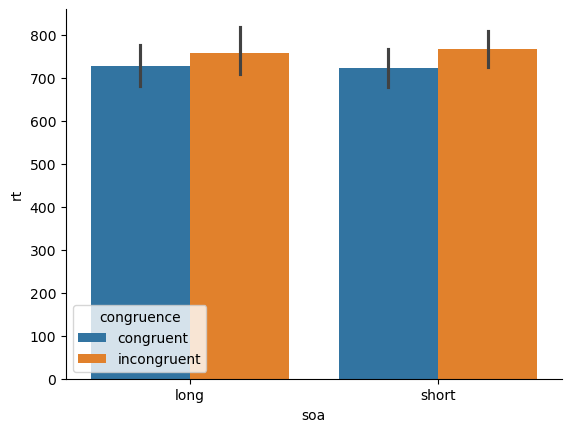

In [147]:
# make barplot of the data.
sns.barplot(data=df_grouped, x='soa', y='rt', hue='congruence')            # make a barplot
sns.despine()                                                              # get rid of the lines around the top and bottom - looks much nicer!

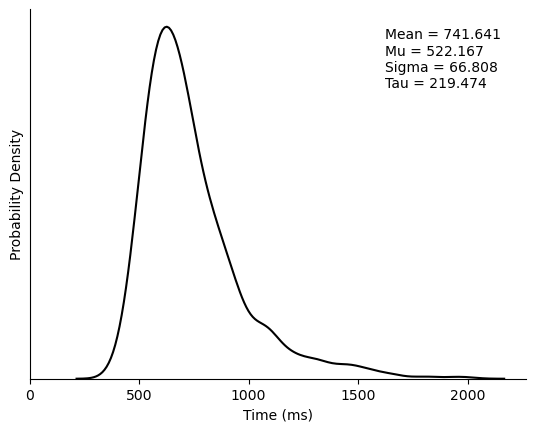

In [ ]:
# Plot our response time data like Balota and Yap (2011) do

# Fit an ex-gaussian function to the data (maximum liklihood estimation)
K, loc, scale = exponnorm.fit(df['rt'])

# exponorm fits an exgaussian function to the data (here our reaction time data)
# It finds the best values for K, loc, and scale
# K = shape parameter. This is the ratio of the exponential tail to the gaussian spread (K = tau/sigma)
# loc = how much the distribution should shift right or left
# scale = sigma (the standard deviation of the gaussian component of the distribution)

# Recover parameters (give them the same names as in Balota & Yap, 2011)
mu    = loc                            # mu is the same as loc
sigma = scale                          # sigma is the same as scale
tau   = K * scale                      # mean of the exponential component
mean = mu + tau                        # the "theoretical" mean of the fitted function
empmean = df['rt'].mean()             # the "empirical" mean of the data (what "mean" normally, uhh.. means)

# Make a figure like the ones in Balota & Yap (2011). 
ax = sns.kdeplot(data = df, x = 'rt', color = 'black')                                  # plot the data as a distribution
# uncomment the next two lines to check the fit of the function to the data
#x = np.linspace(df['rt'].min(), df['rt'].max(), 200)                                   # datapoint for plotting theoretical exgaussian 
#ax.plot(x, exponnorm.pdf(x, K, loc, scale), color='red', linestyle='--')               # plot theoretical exgauss function on top of acutal data (to check fit)
values = f"Mean = {mean:.3f}\nMu = {mu:.3f}\nSigma = {sigma:.3f}\nTau = {tau:.3f}"      # assemble the text for the legend
ax.text(0.95, 0.95, values,                                                             # x and y coordinates for annotations
        transform=ax.transAxes,                                                         # fixes text box to the figure, not the data
        ha='right', va='top',ma='left',                                                 # position and algin the text in the box
        fontsize=10)                                                                    # I mean, yeah. It's the font size
        #bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))                     # make a box around the annotation, if you want
ax.set(xlabel='Time (ms)', ylabel='Probability Density')                                # Change the axis labels
ax.tick_params(left=False, labelleft=False)                                             # Remove the ticks and values on the y-axis
ax.set_xlim(left=0)                                                                     # Start the x-axis at zero
sns.despine()                                                                           # Remove the top and right boundary lines


In [149]:
  
  

quantiles = np.arange(.1, 1.0, .1)  # .1 to .9

# per-subject, per-condition quantiles
df_q = (
    df.groupby(['participant_id', 'congruence'])['rt']
      .apply(lambda x: x.quantile(quantiles))
      .rename_axis(['participant', 'congruence', 'quantile'])
      .reset_index(name='rt_q')
)
df_q # inspect the quantiles


,participant,congruence,quantile,rt_q
0,51,congruent,0.1,469.108
1,51,congruent,0.2,493.104
2,51,congruent,0.3,514.410
3,51,congruent,0.4,542.600
4,51,congruent,0.5,568.970
...,...,...,...,...
337,69,incongruent,0.5,701.200
338,69,incongruent,0.6,750.980
339,69,incongruent,0.7,807.420
340,69,incongruent,0.8,941.040


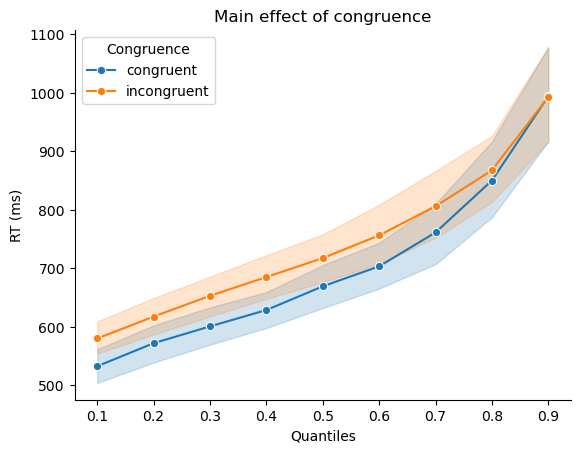

In [119]:


ax = sns.lineplot(data=df_q, x='quantile', y='rt_q', hue='congruence', marker='o')
ax.set(xlabel='Quantiles', ylabel='RT (ms)')

ax.set_title('Main effect of congruence')
ax.set(xlabel='Quantiles', ylabel='RT (ms)')
ax.legend(title='Congruence')
sns.despine()



In [121]:
def plot_vincentile(df, condition_col, ax, rt_col='rt', subject_col='participant_id',
                    quantiles=np.arange(.1, 1.0, .1)):
    df_q = (
        df.groupby([subject_col, condition_col])[rt_col]
        .apply(lambda x: x.quantile(quantiles))
        .rename_axis([subject_col, condition_col, 'quantile'])
        .reset_index(name='rt_q')
    )

    #df_vinc = df_q.groupby([condition_col, 'quantile'])['rt_q'].mean().reset_index()

    sns.lineplot(data=df_q, x='quantile', y='rt_q', hue=condition_col, marker='o', ax=ax)
    ax.set_title(f'Main effect of {condition_col}')
    ax.set(xlabel='Quantiles', ylabel='RT (ms)')
    ax.legend(title=condition_col.capitalize())

    return df_vinc


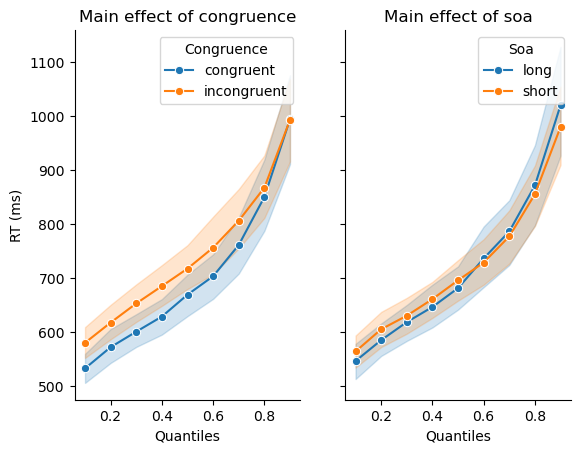

In [122]:

fig, axes = plt.subplots(1,2, sharey=True)
ax1 = plot_vincentile(df, 'congruence', ax = axes[0])
ax2 = plot_vincentile(df, 'soa', ax = axes[1])
sns.despine()

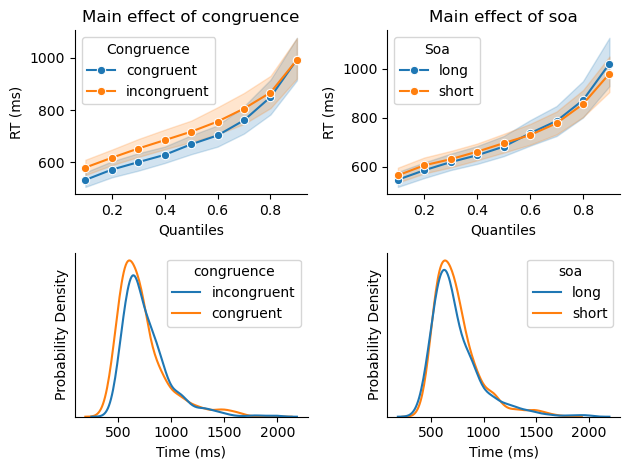

In [123]:

fig, axes = plt.subplots(2,2, sharey=False)
ax1 = plot_vincentile(df, 'congruence', ax = axes[0, 0])
ax2 = plot_vincentile(df, 'soa', ax = axes[0, 1])
ax3 = sns.kdeplot(data = df, x='rt', hue='congruence', ax = axes[1,0])
ax4 = sns.kdeplot(data = df, x='rt', hue='soa', ax = axes[1,1])
ax3.set(xlabel='Time (ms)', ylabel='Probability Density')     
ax3.tick_params(left=False, labelleft=False) 
ax4.set(xlabel='Time (ms)', ylabel='Probability Density')     
ax4.tick_params(left=False, labelleft=False) 
sns.despine()
plt.tight_layout()


In [172]:
def get_parameters(data):
    K, loc, scale = exponnorm.fit(data)
    tau = K * scale
    return pd.Series({'mu': loc,
                        'sigma': scale,
                        'tau': tau,
                        'mean': loc + tau})


In [176]:

df_params = (
    df.groupby(['participant_id', 'congruence'])['rt']
    .apply(get_parameters)
    .unstack()
    .reset_index()
)

In [178]:
df_params.head()

,participant_id,congruence,mu,sigma,tau,mean
0,51,congruent,501.041875,69.440867,82.768098,583.809973
1,51,incongruent,526.914627,19.231250,94.618423,621.533050
2,52,congruent,563.500768,76.807991,157.159240,720.660008
3,52,incongruent,591.653656,8.251652,196.297376,787.951032
4,53,congruent,530.325972,56.157012,157.468564,687.794536


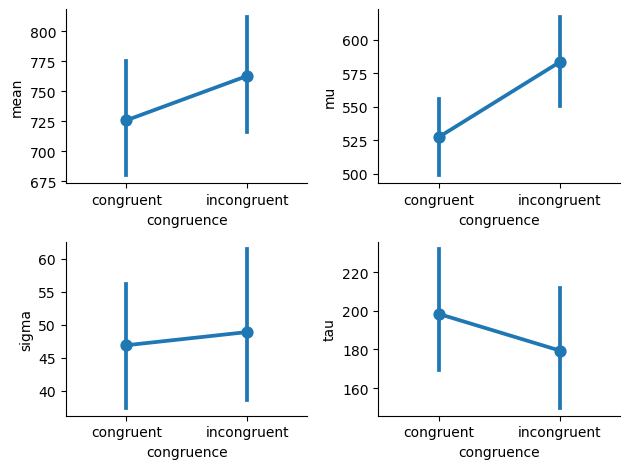

In [187]:
fig, axes = plt.subplots(2,2, sharey=False)
ax1 = sns.pointplot(data=df_params, x='congruence', y='mean', ax=axes[0,0])
ax1 = sns.pointplot(data=df_params, x='congruence', y='mu', ax=axes[0,1])
ax1 = sns.pointplot(data=df_params, x='congruence', y='sigma', ax=axes[1,0])
ax1 = sns.pointplot(data=df_params, x='congruence', y='tau', ax=axes[1,1])
sns.despine()
plt.tight_layout()

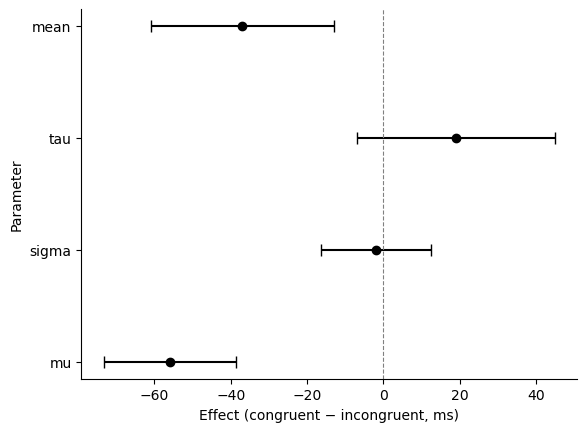

In [188]:
params = ['mu', 'sigma', 'tau', 'mean']

# wide: one row per participant, cols = (param, congruence)
df_wide = df_params.pivot(index='participant_id', columns='congruence', values=params)

results = []
for param in params:
    diff = df_wide[(param, 'congruent')] - df_wide[(param, 'incongruent')]
    mean_diff = diff.mean()
    sem = diff.sem()
    ci95 = 1.96 * sem
    dz = mean_diff / diff.std()  # standardized effect size, Cohen's dz
    results.append({'param': param, 'mean_diff': mean_diff, 'sem': sem, 'ci95': ci95, 'dz': dz})

df_effects = pd.DataFrame(results)

fig, ax = plt.subplots()
ax.errorbar(df_effects['mean_diff'], df_effects['param'], xerr=df_effects['ci95'],
            fmt='o', color='black', capsize=4)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set(xlabel='Effect (congruent − incongruent, ms)', ylabel='Parameter')
sns.despine()

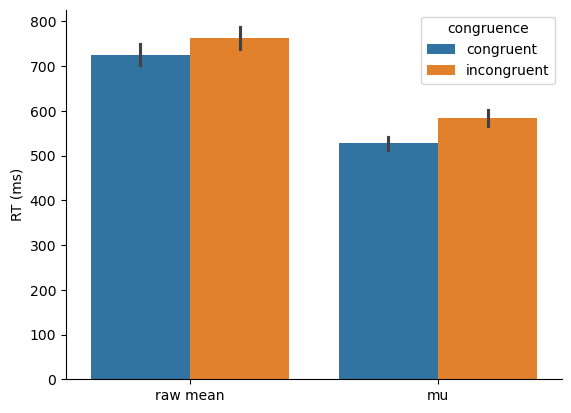

In [189]:
# raw empirical mean RT, per participant per condition
raw_means = df.groupby(['participant_id', 'congruence'])['rt'].mean().reset_index(name='value')
raw_means['param'] = 'raw mean'

# fitted mu, per participant per condition
mu_vals = df_params[['participant_id', 'congruence', 'mu']].rename(columns={'mu': 'value'})
mu_vals['param'] = 'mu'

df_bar = pd.concat([raw_means, mu_vals], ignore_index=True)

ax = sns.barplot(data=df_bar, x='param', y='value', hue='congruence', errorbar='se')
ax.set(xlabel='', ylabel='RT (ms)')
sns.despine()

In [195]:
import pingouin as pg
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, module='scipy')

raw_wide = raw_means.pivot(index='participant_id', columns='congruence', values='value')
t_raw = pg.ttest(raw_wide['congruent'], raw_wide['incongruent'], paired=True)
t_raw


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-3.003933,18,two-sided,0.00762,"[-62.59, -11.07]",0.36177,6.526,0.320597


In [196]:

mu_wide = mu_vals.pivot(index='participant_id', columns='congruence', values='value')
t_mu = pg.ttest(mu_wide['congruent'], mu_wide['incongruent'], paired=True)
t_mu


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-6.304862,18,two-sided,0.000006,"[-74.52, -37.27]",0.782126,3466.506,0.896614


participant_id
68   -146.037101
58   -123.030552
67   -109.557497
54    -75.576925
62    -63.814067
55    -60.795752
64    -60.780908
69    -56.611353
65    -53.011539
60    -52.947401
63    -51.014089
57    -50.477707
61    -49.739186
56    -36.485342
66    -34.870791
52    -28.152888
51    -25.872752
59      5.670548
53     11.057362
dtype: float64


Text(0.5, 0, 'mu diff (congruent − incongruent, ms)')

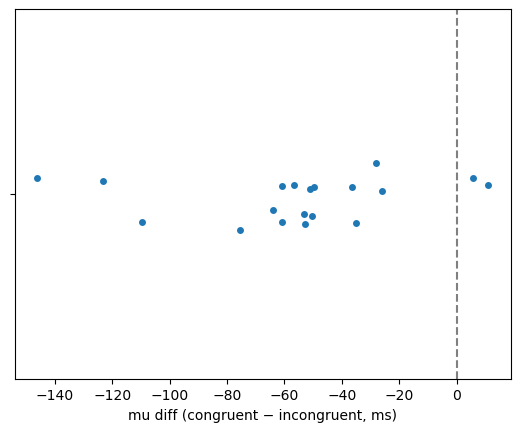

In [ ]:
# sanity check for very large Bayes factor
diff = mu_wide['congruent'] - mu_wide['incongruent']
print(diff.sort_values())

fig, ax = plt.subplots()
sns.stripplot(x=diff, ax=ax)
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('mu diff (congruent − incongruent, ms)')